<a href="https://colab.research.google.com/github/tomasbelak24/deeplearning-vision/blob/main/hw1/deep_net.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Deep web (3pt)

Design a deep (narrow is enough, but have at least 11 layers) network. Test it first without BatchNorm, residual or dense links, or additional training layers. Finally, test at least two of these approaches so that you have at least 3 different models (ie, different placements of these elements).

Note: If you want to test residual or dense connections, design the network in such a way that there is a place to put them.

In [ ]:
!mkdir -p baseline
# I might make the repo private in the future so the files from /baseline directory from the zip file might have to be used
!wget -O baseline/baseline_model.pth https://raw.githubusercontent.com/tomasbelak24/deeplearning-vision/main/hw1/models/baseline_model.pth
!wget -O baseline/baseline_results.json https://raw.githubusercontent.com/tomasbelak24/deeplearning-vision/main/hw1/results/baseline_results.json


--2025-11-12 19:47:19--  https://raw.githubusercontent.com/tomasbelak24/deeplearning-vision/main/hw1/models/baseline_model.pth
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 381333 (372K) [application/octet-stream]
Saving to: ‘baseline/baseline_model.pth’

baseline/baseline_m 100%[===================>] 372.40K  --.-KB/s    in 0.02s   

2025-11-12 19:47:19 (16.3 MB/s) - ‘baseline/baseline_model.pth’ saved [381333/381333]

--2025-11-12 19:47:19--  https://raw.githubusercontent.com/tomasbelak24/deeplearning-vision/main/hw1/results/baseline_results.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443.

In [ ]:
import json

with open('baseline/baseline_results.json', 'r') as f:
    baseline_results = json.load(f)

baseline_train_losses = baseline_results['train_losses']
baseline_val_losses = baseline_results['val_losses']
baseline_val_accs = baseline_results['val_accuracies']

print("Baseline results loaded successfully.")

Baseline results loaded successfully.


In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms

import numpy as np
from matplotlib import pyplot as plt

100%|██████████| 170M/170M [00:04<00:00, 42.4MB/s]


torch.Size([1, 3, 32, 32])


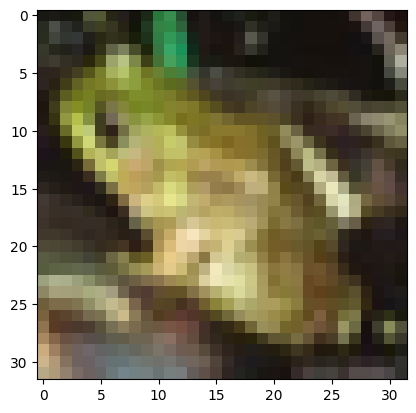

tensor([6])
frog
torch.Size([1, 3, 32, 32])


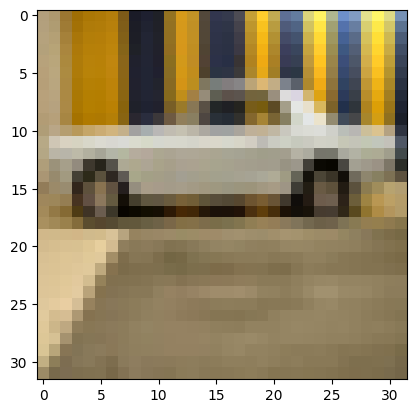

tensor([1])
car
torch.Size([1, 3, 32, 32])


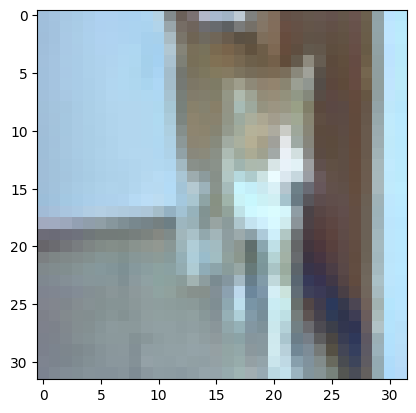

tensor([3])
cat
torch.Size([1, 3, 32, 32])


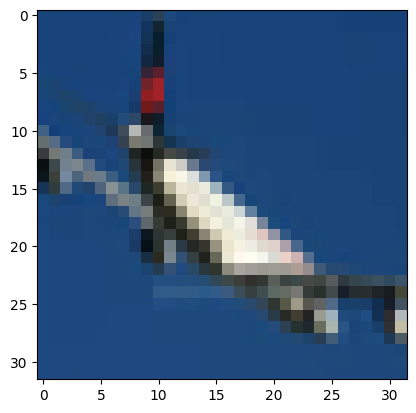

tensor([0])
plane
torch.Size([1, 3, 32, 32])


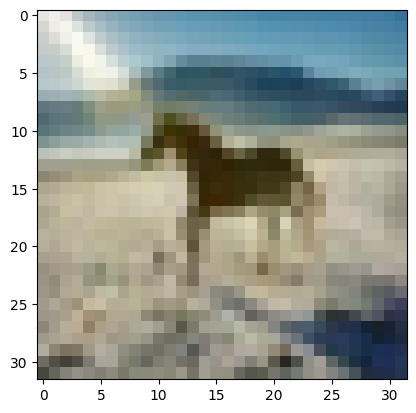

tensor([7])
horse
torch.Size([1, 3, 32, 32])


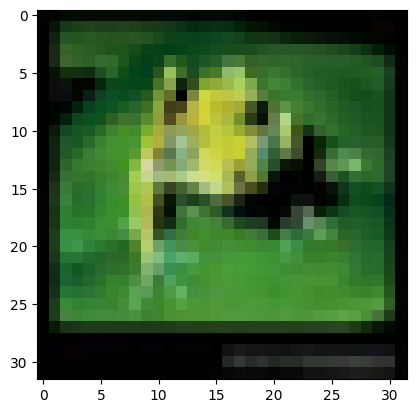

tensor([6])
frog
torch.Size([1, 3, 32, 32])


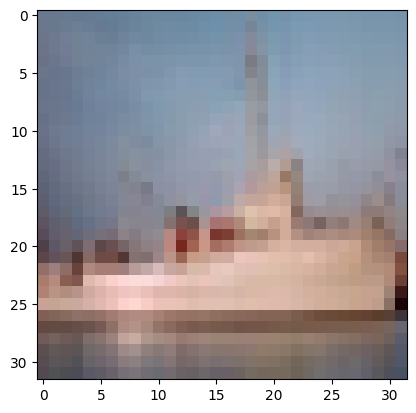

tensor([8])
ship
torch.Size([1, 3, 32, 32])


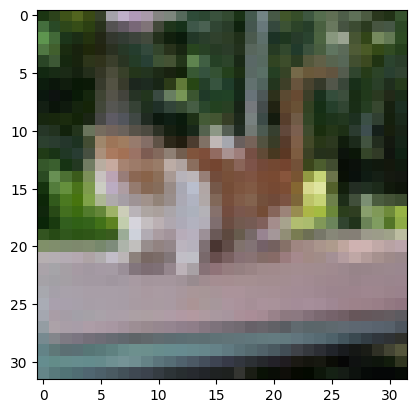

tensor([3])
cat
torch.Size([1, 3, 32, 32])


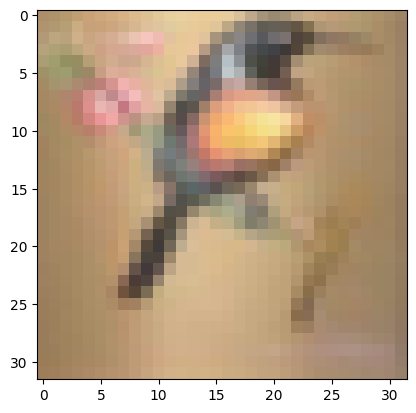

tensor([2])
bird
torch.Size([1, 3, 32, 32])


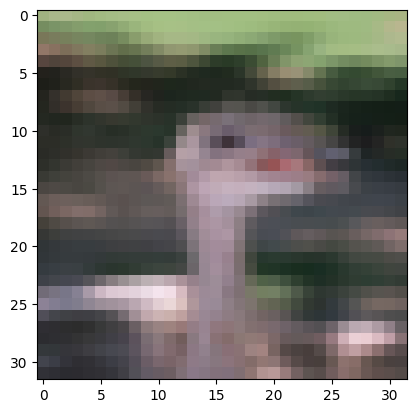

tensor([2])
bird
torch.Size([1, 3, 32, 32])


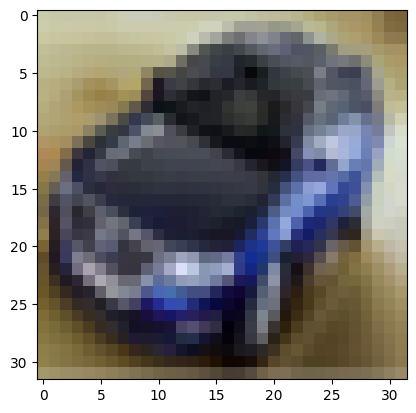

tensor([1])
car


In [ ]:
# @title Loading CIFAR10 dataset

#reused code from the 5th lab

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

transform = transforms.ToTensor()

dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# for reproducibility
trainset, valset = torch.utils.data.random_split(dataset, [45000, 5000], generator=torch.Generator().manual_seed(42))

previewloader = torch.utils.data.DataLoader(testset, batch_size=1, shuffle=True)

for i, sample in enumerate(previewloader):
  if i > 10:
    break
  x, y = sample
  print(x.shape)
  img = np.moveaxis(x.numpy()[0], 0, -1)
  plt.imshow(img)
  plt.show()
  print(y)
  print(classes[y.item()])

In [ ]:
from torch.nn import ReLU, Softmax, Sequential, Linear, Conv2d, MaxPool2d, Flatten, AdaptiveAvgPool2d, Dropout, Dropout2d

def build_model_deep(num_classes=10):
    model = Sequential(
        Conv2d(3, 32, 3, padding=1, bias=True), ReLU(),
        Conv2d(32, 32, 3, padding=1, bias=True), ReLU(),
        Conv2d(32, 32, 3, padding=1, bias=True), ReLU(),
        MaxPool2d(2),

        Conv2d(32, 64, 3, padding=1, bias=True), ReLU(),
        Conv2d(64, 64, 3, padding=1, bias=True), ReLU(),
        Conv2d(64, 64, 3, padding=1, bias=True), ReLU(),
        MaxPool2d(2),

        Conv2d(64, 128, 3, padding=1, bias=True), ReLU(),
        Conv2d(128, 128, 3, padding=1, bias=True), ReLU(),
        Conv2d(128, 128, 3, padding=1, bias=True), ReLU(),
        MaxPool2d(2),

        AdaptiveAvgPool2d(1),
        Flatten(),
        Linear(128, 64), ReLU(),
        Linear(64, num_classes)
    )

    model_inference = Sequential(model, Softmax(dim=1))
    return model, model_inference


def build_model_deep_bn(num_classes=10):
    model = Sequential(
        Conv2d(3, 32, 3, padding=1, bias=True),
        BatchNorm2d(32),
        ReLU(),
        Conv2d(32, 32, 3, padding=1, bias=True),
        BatchNorm2d(32),
        ReLU(),
        Conv2d(32, 32, 3, padding=1, bias=True),
        BatchNorm2d(32),
        ReLU(),
        MaxPool2d(2),

        Conv2d(32, 64, 3, padding=1, bias=True),
        BatchNorm2d(64),
        ReLU(),
        Conv2d(64, 64, 3, padding=1, bias=True),
        BatchNorm2d(64),
        ReLU(),
        Conv2d(64, 64, 3, padding=1, bias=True),
        BatchNorm2d(64),
        ReLU(),
        MaxPool2d(2),

        Conv2d(64, 128, 3, padding=1, bias=True),
        BatchNorm2d(128),
        ReLU(),
        Conv2d(128, 128, 3, padding=1, bias=True),
        BatchNorm2d(128),
        ReLU(),
        Conv2d(128, 128, 3, padding=1, bias=True),
        BatchNorm2d(128),
        ReLU(),
        MaxPool2d(2),

        AdaptiveAvgPool2d(1),
        Flatten(),
        Linear(128, 64),
        ReLU(),
        Linear(64, num_classes)
    )

    model_inference = Sequential(model, Softmax(dim=1))
    return model, model_inference

def build_model_even_deeper(num_classes=10):
    model = Sequential(
        Conv2d(3, 32, 3, padding=1, bias=True), ReLU(),
        Conv2d(32, 32, 3, padding=1, bias=True), ReLU(),
        Conv2d(32, 32, 3, padding=1, bias=True), ReLU(),
        Conv2d(32, 32, 3, padding=1, bias=True), ReLU(),
        MaxPool2d(2),

        Conv2d(32, 64, 3, padding=1, bias=True), ReLU(),
        Conv2d(64, 64, 3, padding=1, bias=True), ReLU(),
        Conv2d(64, 64, 3, padding=1, bias=True), ReLU(),
        Conv2d(64, 64, 3, padding=1, bias=True), ReLU(),
        MaxPool2d(2),

        Conv2d(64, 128, 3, padding=1, bias=True), ReLU(),
        Conv2d(128, 128, 3, padding=1, bias=True), ReLU(),
        Conv2d(128, 128, 3, padding=1, bias=True), ReLU(),
        Conv2d(128, 128, 3, padding=1, bias=True), ReLU(),
        MaxPool2d(2),

        AdaptiveAvgPool2d(1),
        Flatten(),
        Linear(128, 128), ReLU(),
        Linear(128, 64), ReLU(),
        Linear(64, num_classes)
    )

    model_inference = Sequential(model, Softmax(dim=1))
    return model, model_inference


model, model_inference = build_model_deep()

out = model_inference(torch.from_numpy(np.zeros([1, 3, 32, 32], dtype=np.float32)))
print(out.size())
print(out)
print(classes[out.argmax().item()])

torch.Size([1, 10])
tensor([[0.0966, 0.0937, 0.0937, 0.1090, 0.1053, 0.0924, 0.1015, 0.1076, 0.1024,
         0.0979]], grad_fn=<SoftmaxBackward0>)
cat


In [ ]:
def one_epoch(model, loss, optimizer, dataloader_train, dataloader_val, verbose=True):
  train_losses = []
  val_losses = []

  model.train()
  for i, batch in enumerate(dataloader_train):
    x, y = batch[0].to(device), batch[1].to(device)
    optimizer.zero_grad()

    out = model(x)
    loss = ce_loss(out, y)
    loss.backward()
    train_losses.append(loss.item())
    optimizer.step()
    if i % 100 == 0 and verbose:
      print("Training loss at step {}: {}".format(i, loss.item()))

  model.eval()
  with torch.no_grad():
    correct = 0
    total = 0
    for i, batch in enumerate(dataloader_val):
      x, y = batch[0].to(device), batch[1].to(device)

      out = model(x)
      loss = ce_loss(out, y)
      acc = torch.sum(torch.argmax(out, dim=-1) == y)
      correct += acc.item()
      total += len(batch[1])
      val_losses.append(loss.item())

  val_acc = correct / total

  return np.mean(train_losses), np.mean(val_losses), val_acc

Using device:  cuda:0
Trying augmentation setting: augmentation_easy
Val loss at epoch 0: 1.5545264634357137
Val acc at epoch 0: 0.4368
Val loss at epoch 1: 1.4588819932026469
Val acc at epoch 1: 0.4576
Val loss at epoch 2: 1.3166374848906401
Val acc at epoch 2: 0.5288
Val loss at epoch 3: 1.2474148060865462
Val acc at epoch 3: 0.5556
Val loss at epoch 4: 1.1879348971281842
Val acc at epoch 4: 0.5718
Val loss at epoch 5: 1.0954268984733873
Val acc at epoch 5: 0.6138
Val loss at epoch 6: 1.0898022864274919
Val acc at epoch 6: 0.6174
Val loss at epoch 7: 1.059718073932988
Val acc at epoch 7: 0.6242
Val loss at epoch 8: 0.9987527280096795
Val acc at epoch 8: 0.6446
Val loss at epoch 9: 0.9550526536953677
Val acc at epoch 9: 0.6596
Val loss at epoch 10: 1.0382527348342214
Val acc at epoch 10: 0.6404
Val loss at epoch 11: 0.9127467295546441
Val acc at epoch 11: 0.6746
Val loss at epoch 12: 0.8844795331453822
Val acc at epoch 12: 0.6948
Val loss at epoch 13: 0.9703461336102456
Val acc at epo

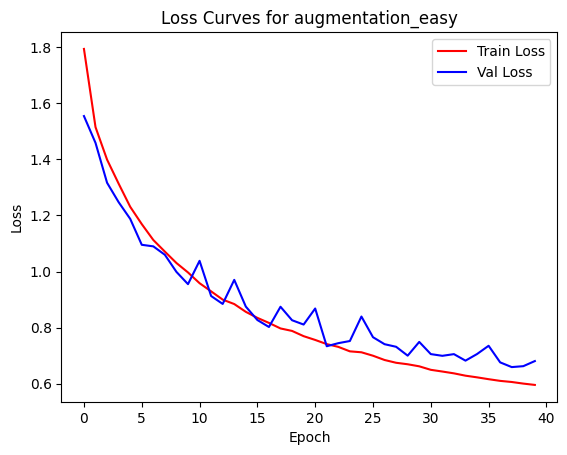

Trying augmentation setting: augmentation_medium
Val loss at epoch 0: 1.516978373952732
Val acc at epoch 0: 0.4508
Val loss at epoch 1: 1.4214688448389625
Val acc at epoch 1: 0.471
Val loss at epoch 2: 1.3100484210974093
Val acc at epoch 2: 0.5228
Val loss at epoch 3: 1.216870512552322
Val acc at epoch 3: 0.5598
Val loss at epoch 4: 1.0958908424255953
Val acc at epoch 4: 0.61
Val loss at epoch 5: 1.0792083375772852
Val acc at epoch 5: 0.6156
Val loss at epoch 6: 1.0705288671384192
Val acc at epoch 6: 0.6218
Val loss at epoch 7: 1.0581841392881552
Val acc at epoch 7: 0.6222
Val loss at epoch 8: 0.929548553410609
Val acc at epoch 8: 0.6762
Val loss at epoch 9: 0.9647134743678342
Val acc at epoch 9: 0.6596
Val loss at epoch 10: 0.9408190324427975
Val acc at epoch 10: 0.664
Val loss at epoch 11: 0.9155627141712578
Val acc at epoch 11: 0.6784
Val loss at epoch 12: 0.9823470899633541
Val acc at epoch 12: 0.6624
Val loss at epoch 13: 0.8796851048423986
Val acc at epoch 13: 0.6886
Val loss at 

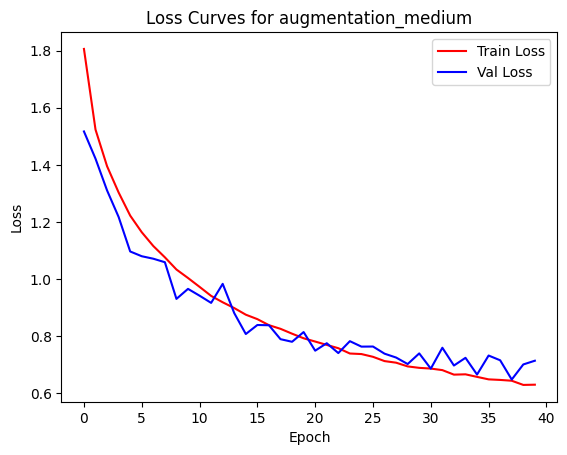

Trying augmentation setting: augmentation_finalBoss
Val loss at epoch 0: 1.667784244391569
Val acc at epoch 0: 0.391
Val loss at epoch 1: 1.5984089116381992
Val acc at epoch 1: 0.4332
Val loss at epoch 2: 1.472879262866488
Val acc at epoch 2: 0.479
Val loss at epoch 3: 1.4602667161613514
Val acc at epoch 3: 0.4904
Val loss at epoch 4: 1.248723613608415
Val acc at epoch 4: 0.544
Val loss at epoch 5: 1.1536020408770082
Val acc at epoch 5: 0.587
Val loss at epoch 6: 1.1421641665659132
Val acc at epoch 6: 0.6
Val loss at epoch 7: 1.0808093973026154
Val acc at epoch 7: 0.6236
Val loss at epoch 8: 1.1190926592061474
Val acc at epoch 8: 0.6036
Val loss at epoch 9: 1.067653566788716
Val acc at epoch 9: 0.6118
Val loss at epoch 10: 0.9960608843025888
Val acc at epoch 10: 0.645
Val loss at epoch 11: 0.9929285201297444
Val acc at epoch 11: 0.6512
Val loss at epoch 12: 0.9963043005603134
Val acc at epoch 12: 0.648
Val loss at epoch 13: 0.9797514536578185
Val acc at epoch 13: 0.655
Val loss at epoc

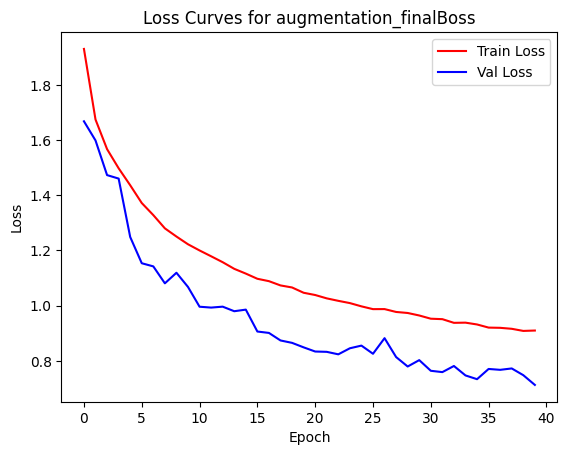

In [ ]:
configs = [{'name': 'deep_net', 'build_model': build_model_deep},
           {'name': 'deep_net_bn', 'build_model': build_model_deep_bn},
           {'name': 'even_deeper_net', 'build_model': build_model_even_deeper}
           ]

losses = {config['name']: ([], []) for config in configs}
accuracies = {config['name']: [] for config in configs}

batch_size = 32

dataloader_train = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
dataloader_val = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device: ", device)

ce_loss = torch.nn.CrossEntropyLoss().to(device)

for config in configs:
    print(f"Trying augmentation setting: {config['name']}")

    build_model = config['build_model']
    model, model_inference = build_model()
    model.to(device)
    model_inference.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    epoch_train_losses = []
    epoch_val_losses = []
    epoch_val_accs = []

    for e in range(80):
        train_loss, val_loss, val_acc = one_epoch(model, ce_loss, optimizer, dataloader_train, dataloader_val, False)

        if e % 4 == 0:
          print(f"Val loss at epoch {e}: {val_loss}")
          print(f"Val acc at epoch {e}: {val_acc}")

        epoch_train_losses.append(train_loss)
        epoch_val_losses.append(val_loss)
        epoch_val_accs.append(val_acc)

    losses[config['name']][0].append(epoch_train_losses)
    losses[config['name']][1].append(epoch_val_losses)
    accuracies[config['name']].append(epoch_val_accs)

    plt.plot(epoch_train_losses, c='r', label='Train Loss')
    plt.plot(epoch_val_losses, c='b', label='Val Loss')
    plt.title(f"Loss Curves for {config['name']}")
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [ ]:
import json

results_to_dump = {
    'losses': losses,
    'accuracies': accuracies
}

output_filename = 'deep_results.json'

with open(output_filename, 'w') as f:
    json.dump(results_to_dump, f)

print(f"Results dumped to {output_filename}")

Results dumped to augmentation_results.json


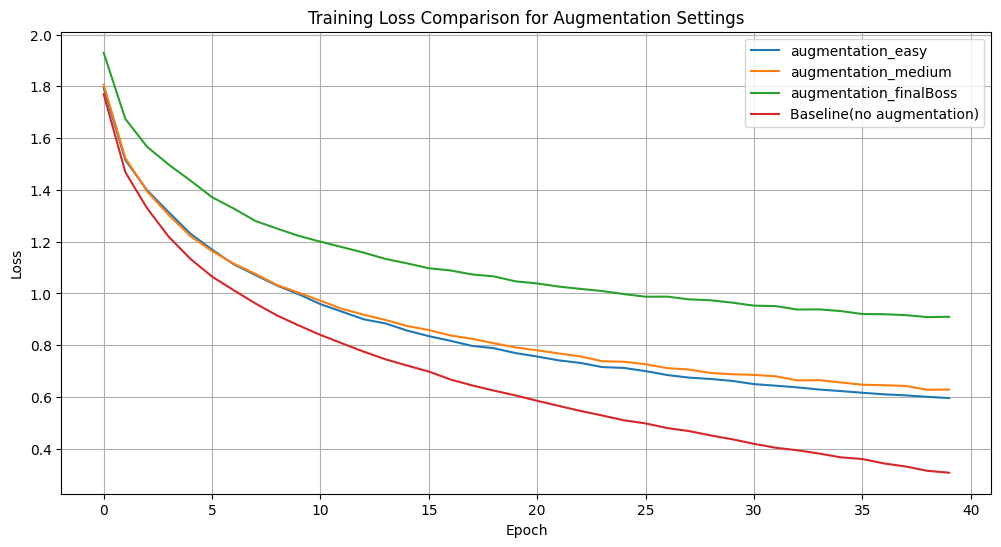

In [ ]:
plt.figure(figsize=(12, 6))
for optimizer_name in configs:
    plt.plot(losses[optimizer_name['name']][0][0], label=optimizer_name['name'])

plt.plot(baseline_train_losses, label='Baseline')

plt.title('Training Loss Comparison for Augmentation Settings')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

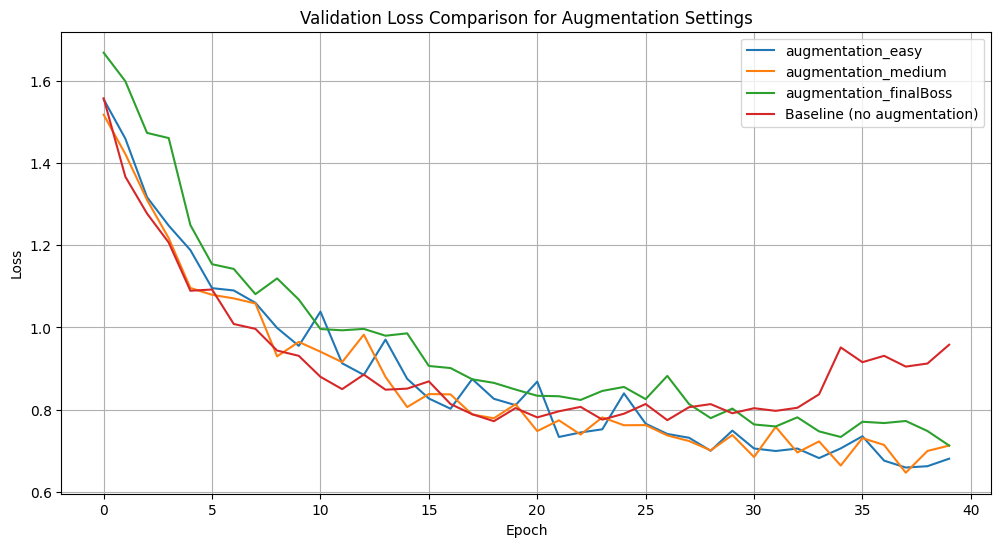

In [ ]:
plt.figure(figsize=(12, 6))
for optimizer_name in configs:
    plt.plot(losses[optimizer_name['name']][1][0], label=optimizer_name['name'])

plt.plot(baseline_val_losses, label='Baseline')

plt.title('Validation Loss Comparison for Deeper networks')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

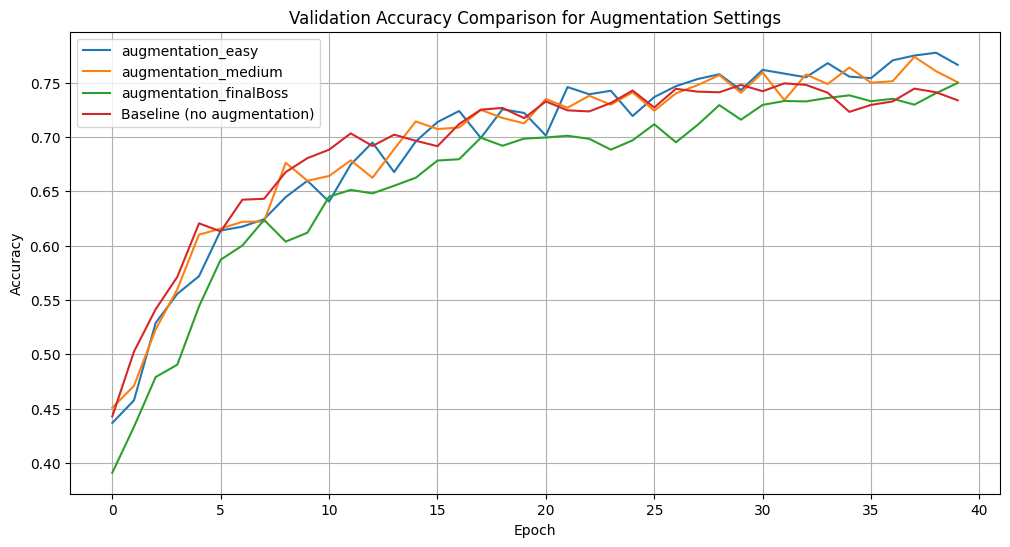

In [ ]:
plt.figure(figsize=(12, 6))
for optimizer_name in configs:
    plt.plot(accuracies[optimizer_name['name']][0], label=optimizer_name['name'])

plt.plot(baseline_val_accs, label='Baseline')

plt.title('Validation Accuracy Comparison for Deeper networks')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd

summary_data = {}

# Get baseline results
summary_data['Baseline'] = {
    'Final Train Loss': baseline_train_losses[-1],
    'Final Val Loss': baseline_val_losses[-1],
    'Final Val Accuracy': baseline_val_accs[-1]
}

# Get results for each optimizer
for config in configs:
    summary_data[config['name']] = {
        'Final Train Loss': losses[config['name']][0][0][-1],
        'Final Val Loss': losses[config['name']][1][0][-1],
        'Final Val Accuracy': accuracies[config['name']][0][-1]
    }

summary_df = pd.DataFrame.from_dict(summary_data, orient='index')
display(summary_df)

,Final Train Loss,Final Val Loss,Final Val Accuracy
Baseline (no augmentation),0.307193,0.957867,0.7336
augmentation_easy,0.595666,0.680770,0.7662
augmentation_medium,0.628581,0.712674,0.7502
augmentation_finalBoss,0.909785,0.712767,0.7496
